<a href="https://colab.research.google.com/github/nanna273/MLEndLS_AB/blob/main/ECS7020P_miniproject_advanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECS7020P mini-project submission

The mini-project has two separate components:


1.   ~~**Basic component** [6 marks]: Using the MLEnd London Sounds dataset, build a machine learning pipeline that takes as an input an audio segment and predicts whether the audio segment has been recorded indoors or outdoors.~~  
2.   **Advanced component** [10 marks]: Formulate your own machine learning problem and build a machine learning solution using the MLEnd London Sounds dataset.  

Your submission will consist of two Jupyter notebooks, one for the basic component and another one for advanced component. Please **name each notebook**:

* ECS7020P_miniproject_basic.ipynb
* ECS7020P_miniproject_advanced.ipynb

then **zip and submit them toghether**.

Each uploaded notebook should include: 

*   **Text cells**, describing concisely each step and results.
*   **Code cells**, implementing each step.
*   **Output cells**, i.e. the output from each code cell.

and **should have the structure** indicated below. Notebooks might not be run, please make sure that the output cells are saved.

How will we evaluate your submission?

*   Conciseness in your writing (10%).
*   Correctness in your methodology (30%).
*   Correctness in your analysis and conclusions (30%).
*   Completeness (10%).
*   Originality (10%).
*   Efforts to try something new (10%).

Suggestion: Why don't you use **GitHub** to manage your project? GitHub can be used as a presentation card that showcases what you have done and gives evidence of your data science skills, knowledge and experience. 

Each notebook should be structured into the following 9 sections:


# 1 Author

**Student Name**:  Anna Burlingsby  
**Student ID**:  210900587



# 2 Problem formulation

Describe the machine learning problem that you want to solve and explain what's interesting about it.  

London is a vibrant city, full of both natural and man-made noises. It is supposed that areas might be distinguished via recordings made in those areas.  

The areas selected for investigation in this notebook are museums and libraries. These are indoor spaces, but different demographics use each - for example, many children are encouraged to learn and interact at the Natural History Museum, whereas the British Library has an expectation of quiet contemplation. Classification as *busy* or *not busy* is the purpose of this notebook.

# 3 Machine Learning pipeline

Describe your ML pipeline. Clearly identify its input and output, any intermediate stages (for instance, transformation -> models), and intermediate data moving from one stage to the next. It's up to you to decide which stages to include in your pipeline.  

Below, the libraries that will be used to address this problem are imported.

In [1]:
from google.colab import drive

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os, sys, re, pickle, glob
import urllib.request
import zipfile

import IPython.display as ipd
from tqdm import tqdm
import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


## 3.1 Overview  

Broadly, the pipeline is divided into the following stages:  
1. Load data, where the raw data is brought into the notebook, and the relevant files are selected.
2. Transformation, where the audio files are processed to extract features.
4. Validation, where models are compared, hyperparamters tuned, and one is selected.
3. Testing, where the selected model is tested before deployment.
6. Training, where the model is re-trained on the whole dataset.
4. Deployment (not covered in this notebook), where models are deployed on unseen data.

# 4 Transformation stage

Describe any transformations, such as feature extraction. Identify input and output. Explain why you have chosen this transformation stage.

## 4.1 Basic features

Several basic features of each recording are extracted:  
- Overall power of the recording.
- Mean of the pitch of the recording.
- Standard deviation of the pitch.
- Fraction of the recording that is voiced.  

## 4.2 More advanced features  

The Python Librosa library contains a range of features that describe audio data. The following will be explored in this notebook:
- Spectral contrast
- Chroma
- MFCC
- RMS
- Spectral centroid
- Spectral bandwidth
- Spectral flatness
- Spectral rolloff.

Due to the time constraints of producing this notebook, any further description of the meaning of each of the advanced features will not be conducted.

# 5 Modelling

Describe the ML model(s) that you will build. Explain why you have chosen them.  

Models should be selected that can make binary classifications of samples. This includes:
- Support Vector Machines (SVM)
- Logistic Regression
- Random Forest.

# 6 Methodology

Describe how you will train and validate your models, how model performance is assesssed (i.e. accuracy, confusion matrix, etc)

The subset of the data used is not balanced for the *busy* vs. *not busy* locations - there 108 *busy* locations and 354 *not busy* locations (more than twice as many). Therefore, using the accuracy of a classifier as a quality metric will not give a good picture - for example, a classifier that classes all spots as *not busy* would have an accuracy of 77 %, which is misleadingly high. Therefore, balanced scoring will be used - i.e. classifiers that 

# 7 Dataset

Describe the dataset that you will use to create your models and validate them. If you need to preprocess it, do it here. Include visualisations too. You can visualise raw data samples or extracted features.

## 7.1 Dataset reduction

### 7.1.1 Introduction to dataset    

A dataset of audio recordings from around London has been collected by students at Queen Mary University of London (QMUL), and is called MLEndLS. The attributes of this raw data are:  
1. file_id - the name of the file e.g. '0001.wav' that will be used as an index.
2. area - the area of London where the file was recorded e.g. 'british' = The British Museum.
3. spot - the spot in the area where the recording was made e.g. 'street' = Great Russel Street.
4. in_out - whether the spot is 'indoor' or 'outdoor'.
5. Participant - the ID of the student who made the recording e.g. 'S151'.
6. Audio file recording - the .wav file that contains the approximately 7 second clip recorded by the participant.

The following is known about how the data was collected:  
- Participants were given the choice of 6 areas they could make recordings in.
- Each area contained 6 spots.
- Participants selected a minimum of 3 areas, and made recordings in all 6 spots of each of those areas. (note: one area, 'british' has only 5 spots, as the proposed spot 'room23' was inaccessible at the time of the recordings').

### 7.1.2 Dataset for advanced problem

For the solution to this problem, only certain spots in the dataset are relevant:  

***Busy*:**  
- Indoors: Royal Festival Hall welcome hub (southbank, royal).
- Indoors: Natural History Museum Hintze Hall (kensington, hintze).
- Indoors: Natural History Museum Fossil Marine Reptiles gallery (kensington, marine).
- Indoors: Natural History Museum Dinosaur gallery (kensington, dinosaur).
 

***Not busy*:**  
- Indoors: British Museum, Great court (british, greatcourt).
- Indoors: British Museum, Room 12 (british, room12).
- ~~Indoors: British Museum, Room 23 (british, room23).~~ excluded due to lack of recordings in this location.
- Indoors: British Library main entrance (euston, library).
- Indoors: British Library, John Ritblat gallery (euston, ritblat).
- Indoors: The National Gallery Central Hall (westend, national). 

~~Note that there are approximately 3x more locations that are 'not busy' as 'busy'. The problem formulation will address this.~~

## 7.2 Uploading data to notebook  

Below, the filenames are loaded into the notebook and the number of MLEndLS audio files is checked.

In [3]:
sample_path = '/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/training/*.wav'
files = glob.glob(sample_path)
len(files)

2497

There are 2500 files in the MLEndLS dataset, which has been manually chnaged to 2497 after the removal of 3 files. Two do not contain data (see section 7.3 below), and one is known to be a mislabelled location ('room13').

The attributes of each file have been provided in a .csv file, and are loaded into a dataframe below.

In [4]:
MLEndLS_df = pd.read_csv('/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/training/MLEndLS.csv').set_index('file_id') 
MLEndLS_df

,area,spot,in_out,Participant
file_id,,,,
0001.wav,british,street,outdoor,S151
0002.wav,kensington,dinosaur,indoor,S127
0003.wav,campus,square,outdoor,S18
0004.wav,kensington,hintze,indoor,S179
0005.wav,campus,square,outdoor,S176
...,...,...,...,...
2496.wav,westend,trafalgar,outdoor,S151
2497.wav,campus,square,outdoor,S6
2498.wav,westend,national,indoor,S96


Below, the desired locations are selected, and the 'busy' vs. 'not busy' classification is added.  

***Busy*:**  
- Indoors: Royal Festival Hall welcome hub (southbank, royal).
- Indoors: Natural History Museum Hintze Hall (kensington, hintze).
- Indoors: Natural History Museum Fossil Marine Reptiles gallery (kensington, marine).
- Indoors: Natural History Museum Dinosaur gallery (kensington, dinosaur).
 

***Not busy*:**  
- Indoors: British Museum, Great court (british, greatcourt).
- Indoors: British Museum, Room 12 (british, room12).
- ~~Indoors: British Museum, Room 23 (british, room23).~~ excluded due to lack of recordings in this location.
- Indoors: British Library main entrance (euston, library).
- Indoors: British Library, John Ritblat gallery (euston, ritblat).
- Indoors: The National Gallery Central Hall (westend, national). 

In [5]:
busy = ['kensingtonhintze', 'kensingtonmarine', 'kensingtondinosaur',
        'southbankroyal']
not_busy = ['britishgreatcourt', 'britishroom12', 'westendnational',
            'Eustonlibrary', 'Eustonritblat']
advanced_list = busy + not_busy

MLEndLS_df['area_spot'] = MLEndLS_df['area'] + MLEndLS_df['spot']
MLEndLS_df_a = MLEndLS_df.loc[MLEndLS_df['area_spot'].isin(advanced_list)]
MLEndLS_df_a['busy'] = MLEndLS_df_a['area_spot'].isin(busy)

# Drop some extraneous columns
#MLEndLS_df_a = MLEndLS_df_a.drop(['in_out', 'Participant'], axis=1)
MLEndLS_df_a

<ipython-input-5-404bb4d72824>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MLEndLS_df_a['busy'] = MLEndLS_df_a['area_spot'].isin(busy)


,area,spot,in_out,Participant,area_spot,busy
file_id,,,,,,
0002.wav,kensington,dinosaur,indoor,S127,kensingtondinosaur,True
0004.wav,kensington,hintze,indoor,S179,kensingtonhintze,True
0013.wav,british,greatcourt,indoor,S66,britishgreatcourt,False
0019.wav,kensington,dinosaur,indoor,S82,kensingtondinosaur,True
0025.wav,british,room12,indoor,S52,britishroom12,False
...,...,...,...,...,...,...
2483.wav,kensington,dinosaur,indoor,S19,kensingtondinosaur,True
2491.wav,westend,national,indoor,S147,westendnational,False
2498.wav,westend,national,indoor,S96,westendnational,False


Summary statistics about the dataframe are presented below.

In [6]:
MLEndLS_df_a.describe(include='all')

,area,spot,in_out,Participant,area_spot,busy
count,462,462,462,462,462,462
unique,5,9,1,169,9,2
top,british,national,indoor,S107,westendnational,False
freq,167,110,462,5,110,354


## 7.3 Data cleaning ##  

Some of the audio files do not contain any information. Below is some code that will identify these files, by opening them and using the librosa library to calculate the sum of their amplitude. Files with a zero amplitude are removed from the dataset.

In [ ]:
# for n, file in enumerate(files):
#   fs = None # Sampling frequency
#   x, fs = librosa.load(files[n], sr=fs)
#   empty_filenames = []
#   if x.sum() == 0:
#     print(file)

Output of above cell:  

```
/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/training/2206.wav  
/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/training/0033.wav
```

The empty files are '2206.wav' and '0033.wav'. These have manually been removed from the Google Drive folder, and the above code will not be run for future executions of this notebook.  

The empty file in the non-existent 'room13' is identified as '0762.wav' below. It has also been manually removed.

In [7]:
MLEndLS_df.loc[MLEndLS_df.spot=='room13']

,area,spot,in_out,Participant,area_spot
file_id,,,,,
0762.wav,british,room13,indoor,S71,britishroom13


In [8]:
to_drop = ['2206.wav', '0033.wav', '0762.wav']
MLEndLS_df = MLEndLS_df.drop(to_drop)

In [9]:
files_a = [file for file in files
                if file.split('/')[-1] in MLEndLS_df_a.index]

## 7.4 Data visualisation  

Below is a code cell that previews an audio file.

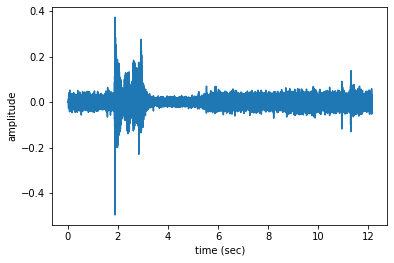

In [166]:
n = 2
fs = None # Sampling frequency
fs = 22050
x, fs = librosa.load(files_a[n],sr=fs)
t = np.arange(len(x))/fs
plt.plot(t,x)
plt.xlabel('time (sec)')
plt.ylabel('amplitude')
plt.show()
display(ipd.Audio(files_a[n]))

According to the instructions, each audio file should contain the participant saying 'this is London' at the start of the recording. This can be seen in the above representative example as the considerably higher peaks early in the audio signal.  

Below, the signal undergoes a Fast Fourier Transform (FFT) to transfrom it into the frequency domain.

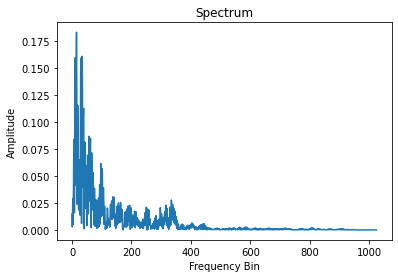

In [167]:
n_fft = 2048
ft = np.abs(librosa.stft(x[:n_fft], hop_length=n_fft+1))
plt.plot(ft)
plt.title('Spectrum')
plt.xlabel('Frequency Bin')
plt.ylabel('Amplitude')
plt.show()

The FFT can be understood as some characteristic frequency peaks. The actual spectral frequency of each peak is not interpretable from the spectrum (it is an arbitrary scale), but this is not required for this ML classification problem.  

Below is shown the Mel spectrogram of the above audio file. This is described here in this link [https://analyticsindiamag.com/a-tutorial-on-spectral-feature-extraction-for-audio-analytics/].

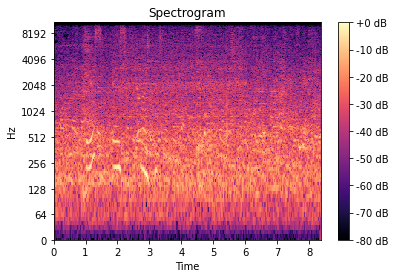

In [12]:
spec = np.abs(librosa.stft(x, hop_length=512))
spec = librosa.amplitude_to_db(spec, ref=np.max)
librosa.display.specshow(spec, sr=fs, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.show()

The Mel spectrogram can be understood as an image of the data as it appears to human ears. One thing that is clear is that the data is not equivariate, and therefore a convolutional neural network should not be used on the raw data. However, the time domain should not be worked in (the time of sounds is arbitrary), and thus the sound should be transformed to the frequency domain for feature extraction.

## 7.5 Feature extraction  

The features that will be used to predict whether sound was recorded indoors or outdoors are extracted from audio recordings.  

The code to extract the files will **not** execute every time the notebook is run, as it will take over 30 minutes. The extracted features have been saved in '.csv' files on a Google drive in section 7.5.3, which is later re-imported into the notebook in section 7.6.

### 7.5.1 Basic features  

First, the librosa library is used to extract the pitch, as well as the portions to the recording that contain voices.

In [13]:
def getPitch(x,fs,winLen=0.02):
  #winLen = 0.02 
  p = winLen*fs
  frame_length = int(2**int(p-1).bit_length())
  hop_length = frame_length//2
  f0, voiced_flag, voiced_probs = librosa.pyin(y=x, fmin=80, fmax=450, sr=fs,
                                                 frame_length=frame_length,hop_length=hop_length)
  return f0,voiced_flag

In [14]:
def getXy_basic(files,labels_file, scale_audio=False, onlySingleDigit=False):
  X_1, X_2, y =[], [], []
  for file in tqdm(files):
    fileID = file.split('/')[-1]
    file_name = file.split('/')[-1]
    yi = labels_file.loc[fileID]['busy']

    fs = None # if None, fs would be 22050
    x, fs = librosa.load(file,sr=fs)

    # Without scaled audio
    f0, voiced_flag = getPitch(x,fs,winLen=0.02)
      
    power = np.sum(x**2)/len(x)
    pitch_mean = np.nanmean(f0) if np.mean(np.isnan(f0))<1 else 0
    pitch_std  = np.nanstd(f0) if np.mean(np.isnan(f0))<1 else 0
    voiced_fr = np.mean(voiced_flag)

    xi1 = [power,pitch_mean,pitch_std,voiced_fr]
    X_1.append(xi1)

    # With scaled audio
    x = x/np.max(np.abs(x))
    f0, voiced_flag = getPitch(x,fs,winLen=0.02)
      
    power = np.sum(x**2)/len(x)
    pitch_mean = np.nanmean(f0) if np.mean(np.isnan(f0))<1 else 0
    pitch_std  = np.nanstd(f0) if np.mean(np.isnan(f0))<1 else 0
    voiced_fr = np.mean(voiced_flag)

    xi2 = [power,pitch_mean,pitch_std,voiced_fr]

    X_2.append(xi2)
    y.append(yi)

  return np.array(X_1), np.array(X_2), np.array(y)

In [15]:
# fileID = [file.split('/')[-1] for file in files_a]

In [ ]:
# X_1, X_2, y_1 = getXy_basic(files_a, labels_file=MLEndLS_df_a, scale_audio=True, onlySingleDigit=True)

100%|██████████| 462/462 [26:02<00:00,  3.38s/it]


In [ ]:
# df_basic_scaled = pd.DataFrame(X_1, index=fileID)
# df_basic_scaled['busy'] = y_1
# df_basic_scaled = df_basic_scaled.rename(
#     columns={0:'power', 1:'pitch_mean', 2:'pitch_std', 3:'voiced_fr'})

# df_basic_unscaled = pd.DataFrame(X_2, index=fileID)
# df_basic_unscaled['busy'] = y_1
# df_basic_unscaled = df_basic_unscaled.rename(
#     columns={0:'power', 1:'pitch_mean', 2:'pitch_std', 3:'voiced_fr'})
# df_basic_unscaled

,power,pitch_mean,pitch_std,voiced_fr,busy
1506.wav,0.002021,133.218089,5.272707,0.036364,False
1516.wav,0.026493,215.337628,21.327012,0.051318,False
1531.wav,0.002208,133.074084,21.050847,0.052531,False
1532.wav,0.008542,124.728313,14.096215,0.065740,False
1534.wav,0.012634,187.624612,27.794105,0.110379,True
...,...,...,...,...,...
0472.wav,0.009638,155.734005,25.552354,0.056730,True
0479.wav,0.006745,204.073055,57.987995,0.059420,False
0483.wav,0.015817,132.159882,8.819580,0.071429,False
0491.wav,0.008435,254.176308,6.404413,0.025145,False


### 7.5.2 STFT  

A number of features can be extracted from the data via the librosa library. Due to the time constraints of this project, domain understanding of these will not be sought. Other methods will be used to determine useful potential features for model fitting. The 'librosa.feature' methods give a total of 44 potential features to investigate. The code is run twice, once with, and once without audio scaling. Both will be investigated.

In [16]:
def getXy_STFT(files,labels_file, scale_audio=False):
  X,y =[],[]
  for file in tqdm(files):
    fileID = file.split('/')[-1]
    file_name = file.split('/')[-1]

    fs = 22050 # if None, fs would be 22050
    x, fs = librosa.load(file,sr=fs)
    if scale_audio: x = x/np.max(np.abs(x))
    n_fft = 2048
    ft = np.abs(librosa.stft(x[:n_fft], hop_length=n_fft+1))
    sc = librosa.feature.spectral_contrast(S=ft, sr=fs) # features 0-6
    ch = librosa.feature.chroma_stft(S=ft, sr=fs) # features 7-19
    mf = librosa.feature.mfcc(S=ft, sr=fs) # features 20-39
    rm = librosa.feature.rms(S=ft) # feature 40
    st = librosa.feature.spectral_centroid(S=ft, sr=fs) # feature 41
    sb = librosa.feature.spectral_bandwidth(S=ft, sr=fs) # features 42
    sf = librosa.feature.spectral_flatness(S=ft) # feature 43
    sr = librosa.feature.spectral_rolloff(S=ft, sr=fs) # feature 44

    features = [sc.T, ch.T, mf.T, rm.T, st.T, sb.T, sf.T, sr.T]

    xi = np.concatenate((features), axis=1)[0]

    X.append(xi)

  return np.array(X)

In [ ]:
# X_3 = getXy_STFT(files_a, labels_file=MLEndLS_df_a, scale_audio=True)

  2%|▏         | 7/462 [00:02<03:00,  2.53it/s]/usr/local/lib/python3.8/dist-packages/librosa/core/pitch.py:153: UserWarning: Trying to estimate tuning from empty frequency set.
  warnings.warn("Trying to estimate tuning from empty frequency set.")
100%|██████████| 462/462 [02:55<00:00,  2.64it/s]


In [ ]:
# df_stft_scaled = pd.DataFrame(X_3,index=fileID)

In [ ]:
# X_4 = getXy_STFT(files_a, labels_file=MLEndLS_df_a, scale_audio=False)

100%|██████████| 462/462 [02:54<00:00,  2.64it/s]


In [ ]:
# df_stft_unscaled = pd.DataFrame(X_4, index=fileID)
# df_stft_unscaled

,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
1506.wav,10.987165,20.339903,19.212850,13.528219,22.076296,25.539422,40.913780,0.838435,0.732121,0.678769,...,-0.000023,-0.000016,-0.000002,-0.000007,-0.000006,1.483665e-07,3003.053522,2554.330692,0.884327,5996.997070
1516.wav,27.171028,24.967471,24.425354,25.900981,22.705612,25.111566,26.409309,0.851757,0.838041,1.000000,...,-0.173867,-0.384078,-0.487583,-0.408744,-0.522795,7.648251e-03,1523.228172,1995.570541,0.003564,3003.881836
1531.wav,18.109955,14.275800,20.413946,17.777177,21.301632,28.000415,49.630094,0.930514,0.861072,0.831439,...,-0.003354,-0.015305,-0.010110,0.002052,0.000347,4.917125e-04,1418.050322,1643.669755,0.003061,3143.847656
1532.wav,21.984720,10.796778,16.865395,18.507653,25.763406,22.504553,34.512151,0.843230,0.814503,0.687101,...,-0.032032,-0.324249,-0.495422,-0.557833,-0.707009,1.768000e-02,1108.012758,1390.052970,0.000655,2153.320312
1534.wav,33.345977,19.193214,12.721722,29.251557,21.301903,23.192450,53.635134,0.767140,0.770380,1.000000,...,-0.154431,-0.089455,-0.109628,-0.105327,-0.041222,7.360834e-03,1314.161127,1725.312133,0.003005,2379.418945
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0472.wav,25.290737,21.802089,14.920692,16.327768,25.181922,23.223237,50.450801,0.878415,0.922825,0.722550,...,-0.289571,-0.324606,-0.345806,-0.358179,-0.342175,2.157327e-03,1801.729099,1953.064075,0.009404,3520.678711
0479.wav,19.277711,17.513755,20.038524,29.611686,24.582573,25.863803,36.496014,0.820287,0.584698,0.623987,...,0.229490,0.146969,-0.015591,-0.268475,-0.594123,1.307974e-02,1325.732246,1553.117503,0.000792,2853.149414
0483.wav,19.792759,9.966521,25.944634,19.047873,18.923113,25.313077,25.511533,0.784158,0.996292,0.669891,...,-0.883308,-1.159248,-1.104367,-0.814604,-1.081740,1.328110e-02,1870.791382,2161.930228,0.011552,3692.944336
0491.wav,17.697577,30.877082,28.484881,24.694003,27.406281,25.942732,53.662472,0.811939,1.000000,0.991419,...,-0.798448,-0.948832,-1.023078,-1.067186,-1.132565,8.386265e-03,1237.027666,1504.589535,0.000820,2336.352539


### 7.5.3 Combining features  

Below the basic and FFT features are combined into 2 dataframes, one with scaled audio and one without. Each of these is saved to a '.csv' file on the Google drive, so that repeated iterations of the notebook will not need to run the functions. The files have been manually renamed in the folder to avoid writing over them in error.

In [18]:
# df_scaled = pd.concat([df_stft_scaled, df_basic_scaled], axis=1)
# df_scaled.to_csv('/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/scaled_features.csv')

In [ ]:
# df_unscaled = pd.concat([df_stft_unscaled, df_basic_unscaled], axis=1)
# df_unscaled.to_csv('/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/unscaled_features.csv')

## 7.6 Feature selection  

Not all the features will correlate with the target variable. A PCA will be conducted, and the coefficients analysed to select features for modelling.  

First, the feature data is re-introduced to the notebook.

In [19]:
scaled_path = '/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/scaled_features_a_221207.csv'
unscaled_path = '/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/unscaled_features_a_221207.csv'
df_scaled = pd.read_csv(scaled_path, index_col=0)
df_unscaled = pd.read_csv(unscaled_path, index_col=0)

In [22]:
df_unscaled

,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,power,pitch_mean,pitch_std,voiced_fr,busy
1506.wav,10.987165,20.339903,19.212850,13.528219,22.076296,25.539422,40.913780,0.838435,0.732121,0.678769,...,1.483665e-07,3003.053522,2554.330692,0.884327,5996.997070,0.002021,133.218089,5.272707,0.036364,False
1516.wav,27.171028,24.967471,24.425354,25.900981,22.705612,25.111566,26.409309,0.851757,0.838041,1.000000,...,7.648251e-03,1523.228172,1995.570541,0.003564,3003.881836,0.026493,215.337628,21.327012,0.051318,False
1531.wav,18.109955,14.275800,20.413946,17.777177,21.301632,28.000415,49.630094,0.930514,0.861072,0.831439,...,4.917125e-04,1418.050322,1643.669755,0.003061,3143.847656,0.002208,133.074084,21.050847,0.052531,False
1532.wav,21.984720,10.796778,16.865395,18.507653,25.763406,22.504553,34.512151,0.843230,0.814503,0.687101,...,1.768000e-02,1108.012758,1390.052970,0.000655,2153.320312,0.008542,124.728313,14.096215,0.065740,False
1534.wav,33.345977,19.193214,12.721722,29.251557,21.301903,23.192450,53.635134,0.767140,0.770380,1.000000,...,7.360834e-03,1314.161127,1725.312133,0.003005,2379.418945,0.012634,187.624612,27.794105,0.110379,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0472.wav,25.290737,21.802089,14.920692,16.327768,25.181922,23.223237,50.450801,0.878415,0.922825,0.722550,...,2.157327e-03,1801.729099,1953.064075,0.009404,3520.678711,0.009638,155.734005,25.552354,0.056730,True
0479.wav,19.277711,17.513755,20.038524,29.611686,24.582573,25.863803,36.496014,0.820287,0.584698,0.623987,...,1.307974e-02,1325.732246,1553.117503,0.000792,2853.149414,0.006745,204.073055,57.987995,0.059420,False
0483.wav,19.792759,9.966521,25.944634,19.047873,18.923113,25.313077,25.511533,0.784158,0.996292,0.669891,...,1.328110e-02,1870.791382,2161.930228,0.011552,3692.944336,0.015817,132.159882,8.819580,0.071429,False
0491.wav,17.697577,30.877082,28.484881,24.694003,27.406281,25.942732,53.662472,0.811939,1.000000,0.991419,...,8.386265e-03,1237.027666,1504.589535,0.000820,2336.352539,0.008435,254.176308,6.404413,0.025145,False


Below, histograms of each of the 48 variables are plotted, coloured by whether the spot is *busy* or *not busy*. Note that, due to the class imbalance, the y-scales for *busy* and *not busy* are different.

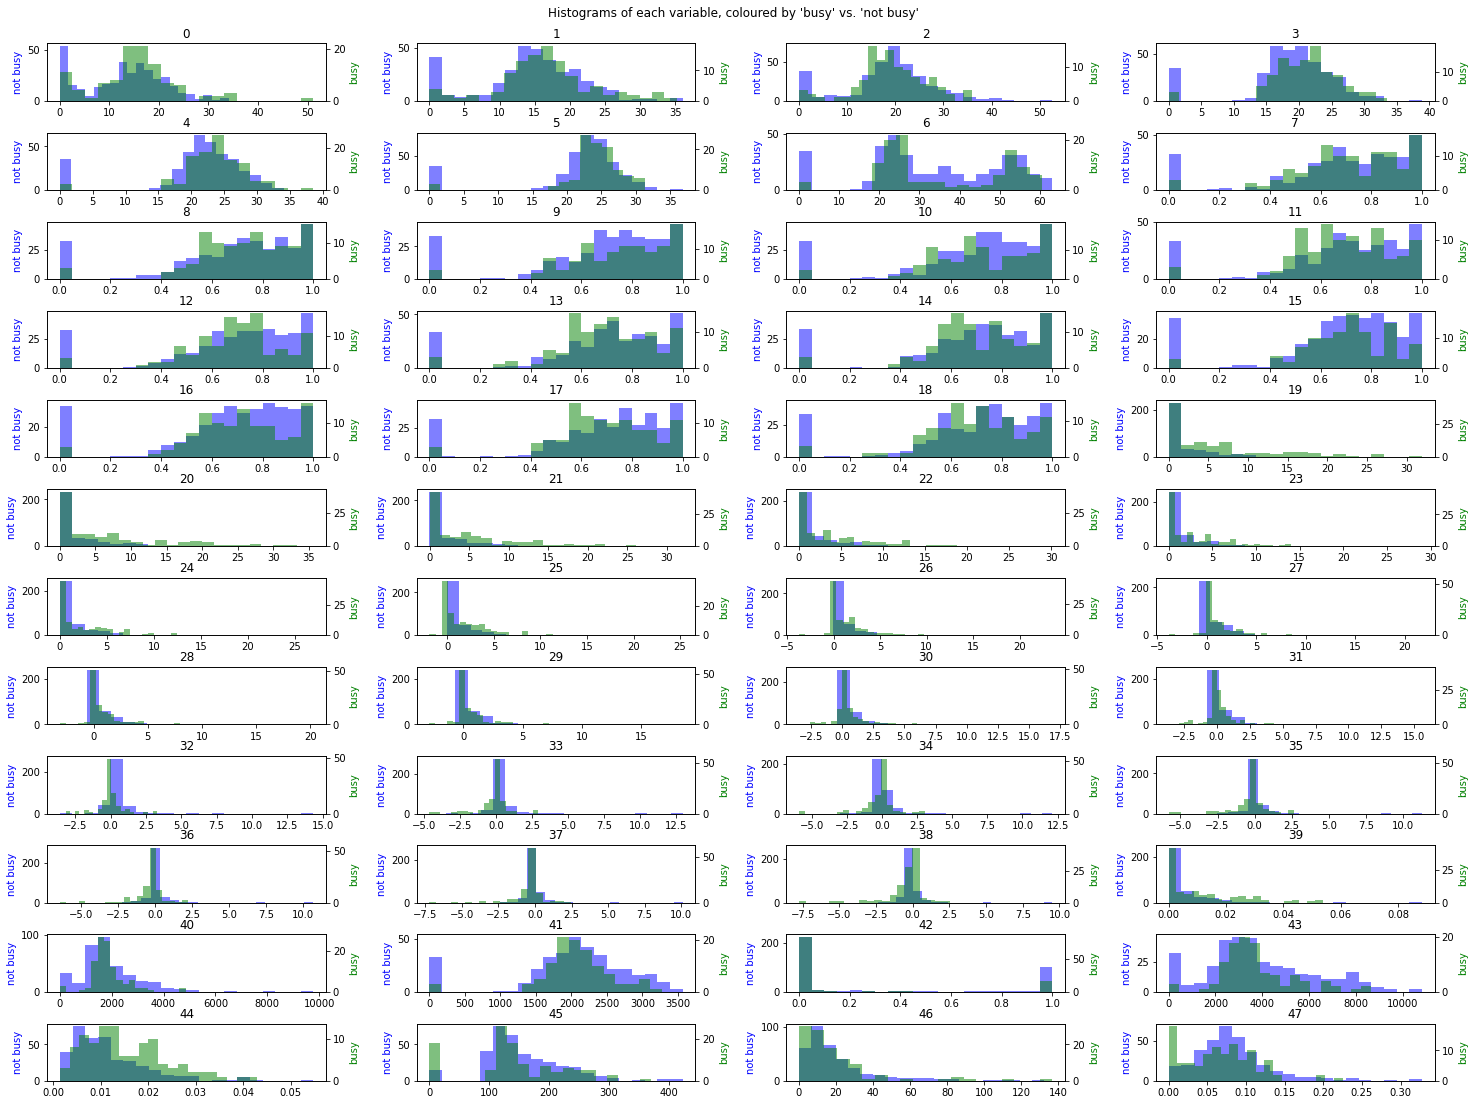

In [47]:
fig, axs = plt.subplots(12, 4, figsize=(20,15))
fig.tight_layout(w_pad=6)
fig.suptitle('Histograms of each variable, coloured by \'busy\' vs. \'not busy\'', y=1.02)

for i in range(48):
  ax1 = axs[i//4, i%4]
  ax2 = ax1.twinx()
  ax1.hist(df_unscaled.iloc[:,i].loc[df_unscaled['busy']==False],
                      bins=20, color='b', alpha=0.5)
  ax2.hist(df_unscaled.iloc[:,i].loc[df_unscaled['busy']==True],
                      bins=20, color='g', alpha=0.5)
  ax1.set_ylabel('not busy', color='b')
  ax2.set_ylabel('busy', color='g')
  ax1.set_title(i)

plt.show()

Possibly due to the scaling and influence of outliers, the histograms do not immediately show any clear differences between the *busy* vs. *not busy* classes.

### 7.6.1 Train test split  

To avoid data leakage, the dataset will be split before any further analysis or feature extraction. This will be stratified by the *busy* class - as there are more *not busy* than *busy* labels in the dataset, the proportions of each of these will be preserved in the train-test split.

In [48]:
y = df_unscaled.pop('busy')

In [49]:
area_spot = np.array([[MLEndLS_df_a.loc[file, 'area_spot']] for file in fileID])
encoder = OrdinalEncoder()
area_spot = encoder.fit_transform(area_spot)
df_unscaled['area_spot'] = area_spot

In [89]:
X = np.array(df_unscaled)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((369, 49), (93, 49), (369,), (93,))

In [90]:
area_spot_train = X_train[:, -1]
X_train = X_train[:, :-1]

### 7.6.2 Visualisations for feature reductions  

Below are presented some representations of how well each feature correlates with the target variable. Boxplots indicate the median and distributions. Any significant difference in distribution has the potential to be exploited for feature selection.

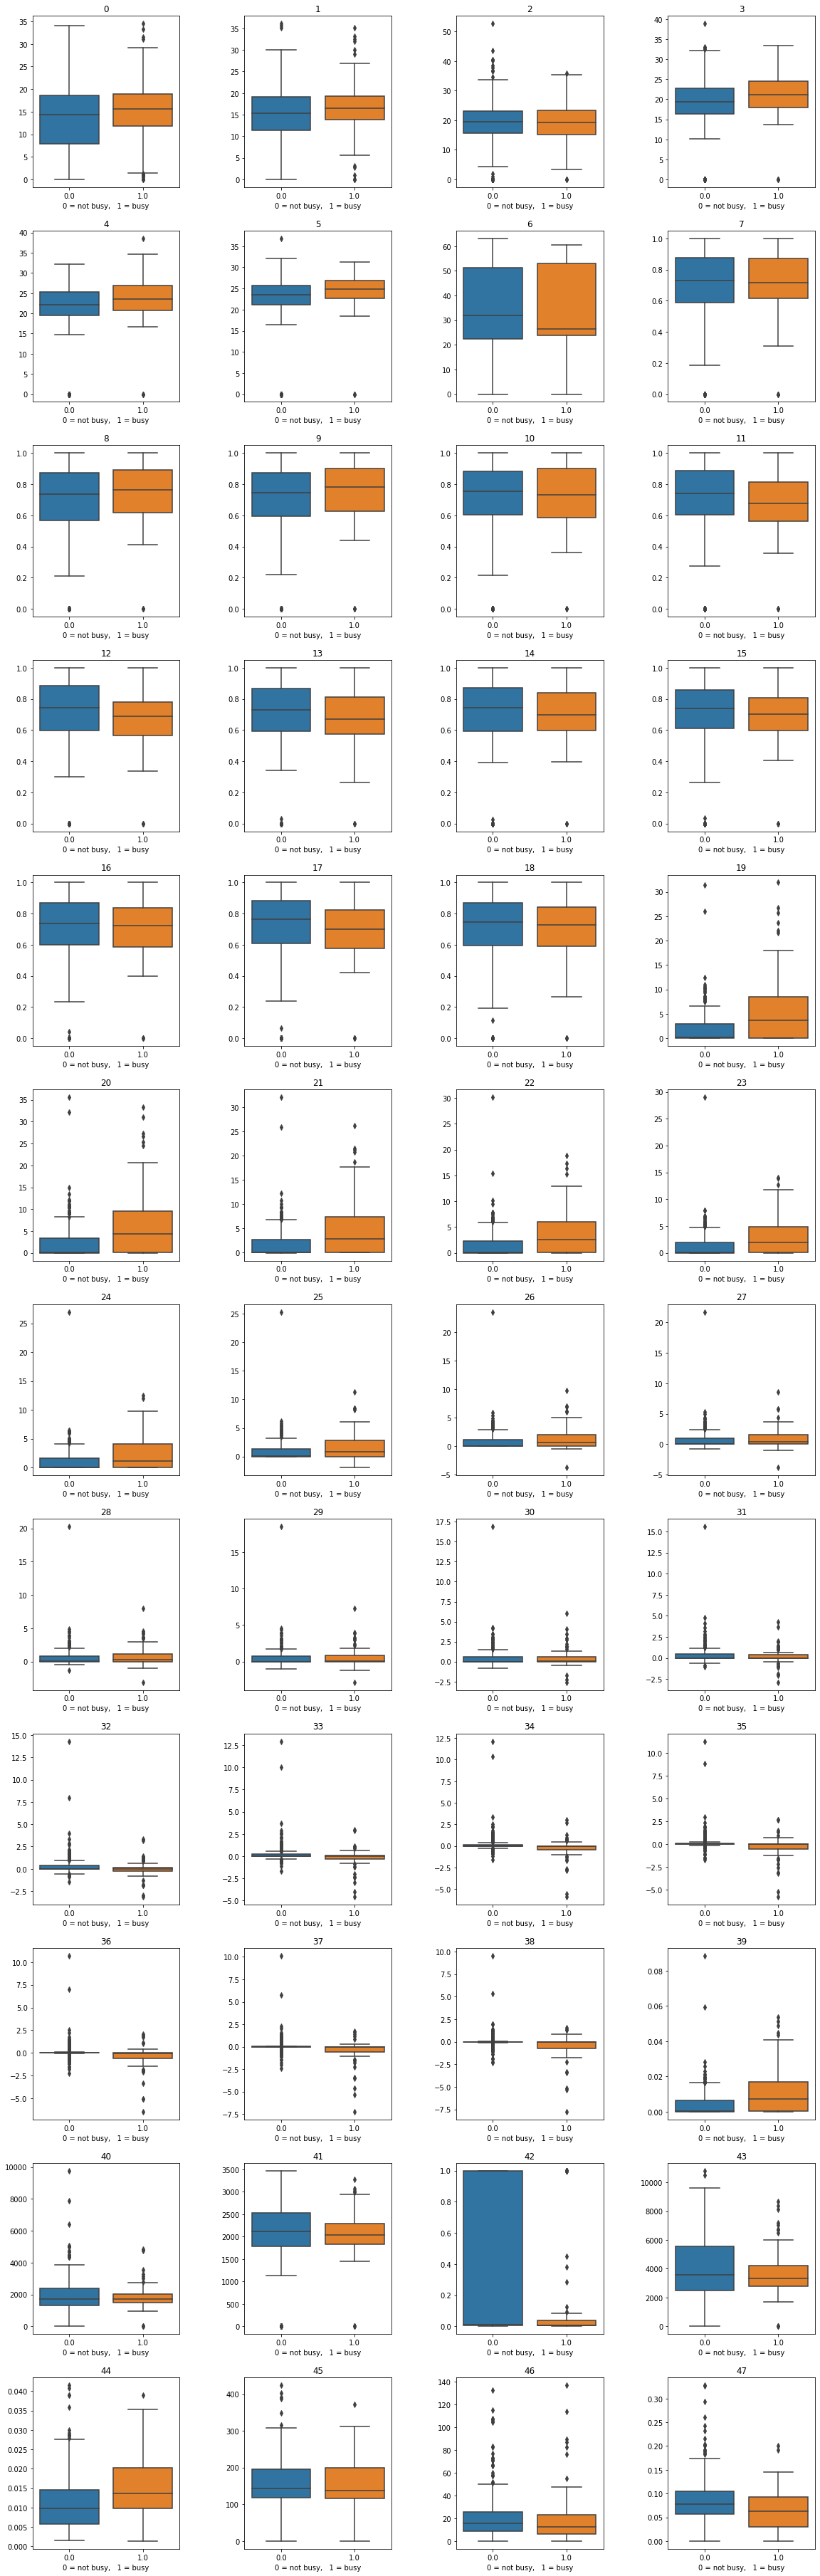

In [60]:
data = pd.DataFrame(np.column_stack((X_train, y_train)))
data = data.rename(columns={48:'y'})

fig, axs = plt.subplots(12, 4, figsize=(16,50))
fig.tight_layout(w_pad=6, h_pad=4)

for i in range(48):
  ax = axs[i//4, i%4]
  sns.boxplot(data=data, y=i, x='y', ax=ax)
  ax.set_ylabel('')
  ax.set_xlabel('0 = not busy,   1 = busy')
  ax.set_title(i)
plt.show()

And now with the outliers (fliers) hidden. Compared to the plots above, and the previously shown histograms, this should allow more subtle differences to be seen.

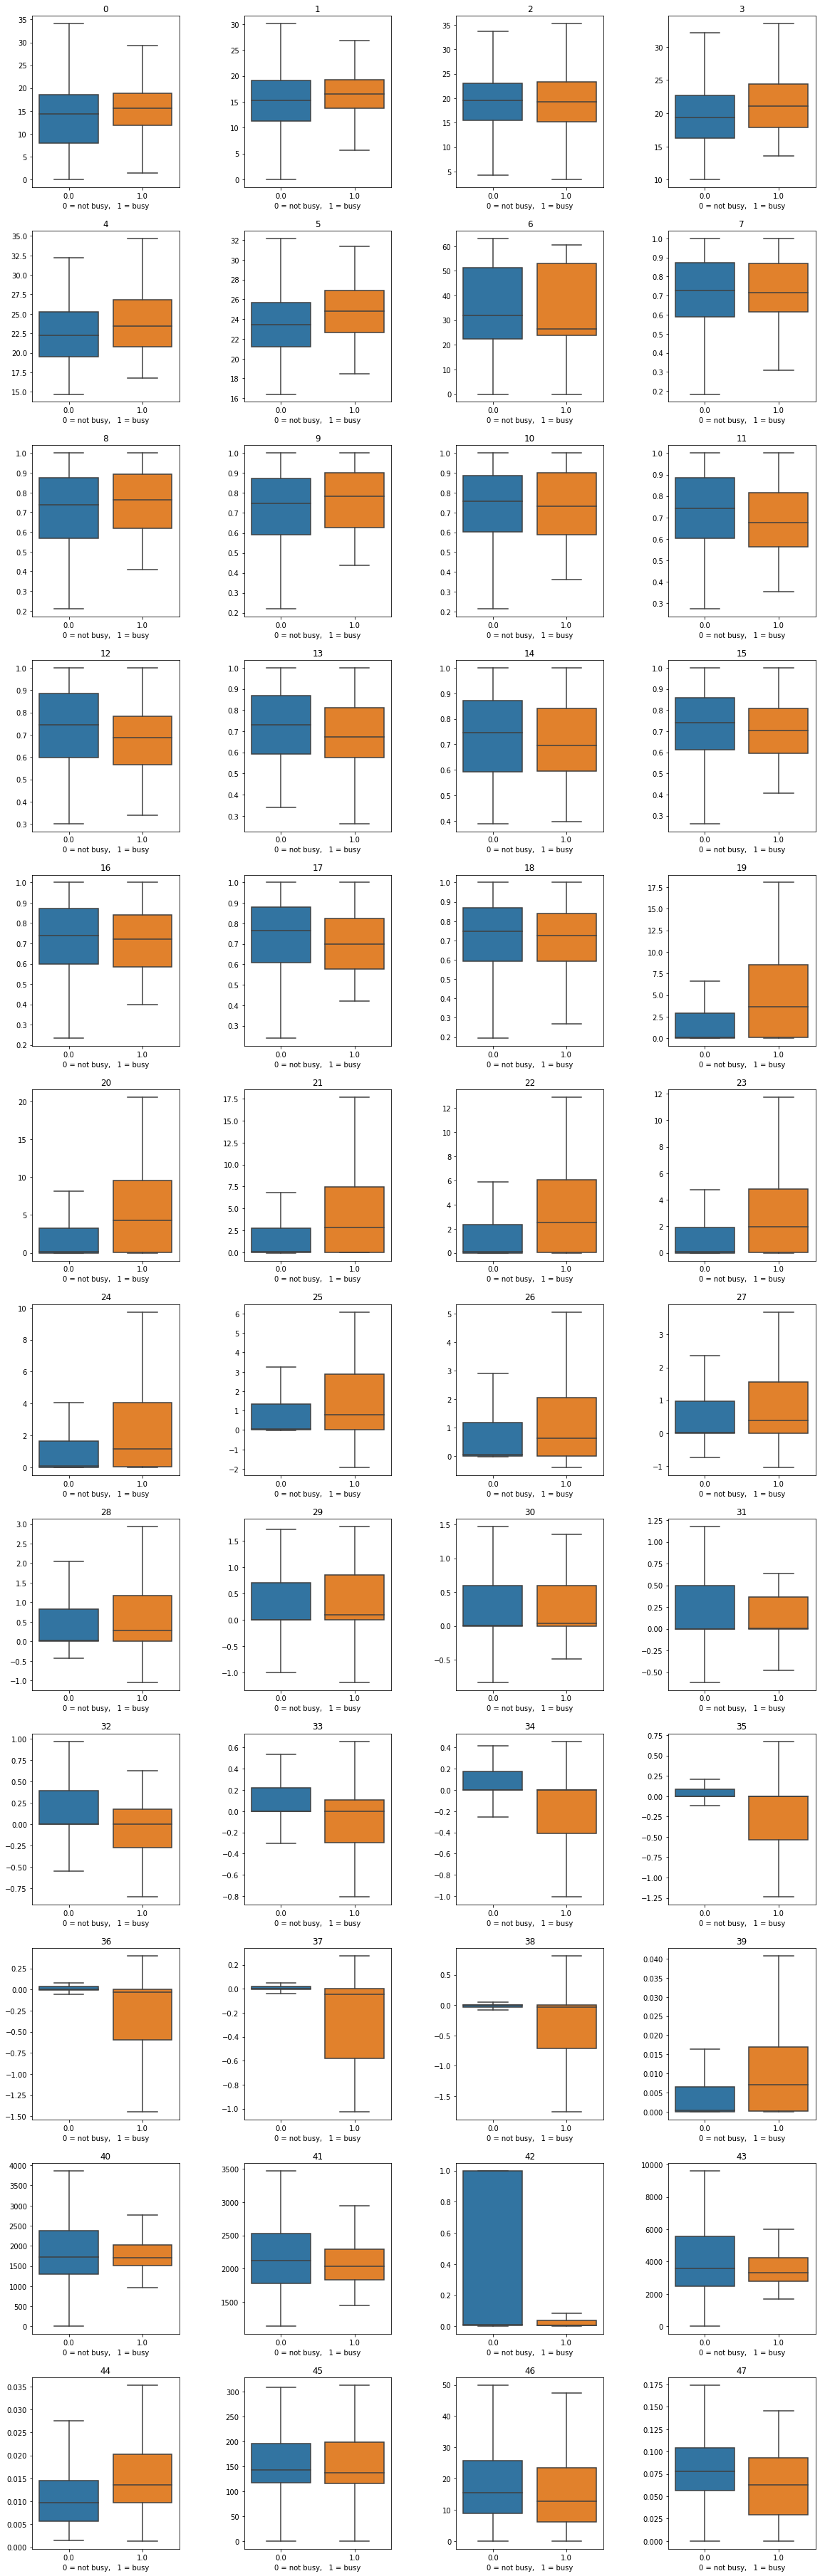

In [59]:
fig, axs = plt.subplots(12, 4, figsize=(16,50))
fig.tight_layout(w_pad=6, h_pad=4)

for i in range(48):
  ax = axs[i//4, i%4]
  sns.boxplot(data=data, y=i, x='y', ax=ax, showfliers=False)
  ax.set_ylabel('')
  ax.set_xlabel('0 = not busy,   1 = busy')
  ax.set_title(i)
plt.show()

With the fliers hidden, there appears to be some correlation between 34-38 plus 42, and the target variable (as well as maybe 33, but less so). Therefore, modelling with only these features will be compared to modelling with all features.

# PCA

In [91]:
#MLEndLS_df_a.loc[MLEndLS_df_a.index.isin(fileID)]
sc = StandardScaler()
X_scaled = sc.fit_transform(X_train[:, [34, 35, 36, 37, 38, 42]])
pca = PCA(n_components=2)
pca = pca.fit(X_scaled)
print(pca.explained_variance_ratio_)
pca = pca.transform(X_scaled)

[0.78593378 0.16949231]


In [92]:
df_pca = pd.DataFrame(data=pca, columns=['PC1', 'PC2'])

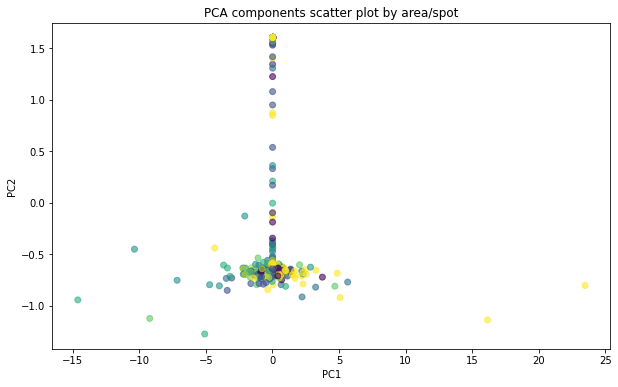

In [103]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot()
p = ax.scatter(df_pca.PC1, df_pca.PC2,c=area_spot_train, alpha=0.6)
ax.set_title('PCA components scatter plot by area/spot')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.show()

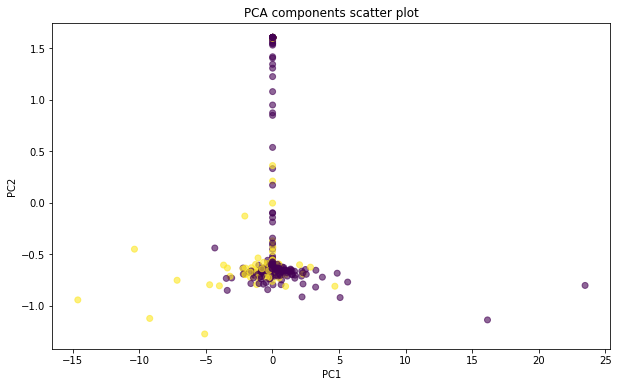

In [106]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot()
p = ax.scatter(df_pca.PC1, df_pca.PC2,c=y_train, alpha=0.6)
ax.set_title('PCA components scatter plot')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.show()

# 8 Results

Carry out your experiments here, explain your results.  

## 8.1 Model selection and validation  

### 8.1.1 Grid search  

The best parameters for the SVC model will be selected using sklearn's grid search function.

In [152]:
# defining parameter range
param_grid = {'classifier__C': [0.1, 1, 10, 100, 1000], 
              'classifier__gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'classifier__kernel': ['rbf'],
              'classifier__class_weight' : ['balanced']}

pipe = Pipeline(steps = [('scaler', StandardScaler()), ('classifier', svm.SVC())])

from sklearn.metrics import roc_curve, precision_recall_curve, auc, make_scorer, recall_score, accuracy_score, precision_score, confusion_matrix  
grid = GridSearchCV(pipe, param_grid, refit='recall_score', verbose=3, cv=3, scoring=make_scorer(recall_score))
  
# fitting the model for grid search
_ = grid.fit(X_train_1, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
[CV 1/3] END classifier__C=0.1, classifier__class_weight=balanced, classifier__gamma=1, classifier__kernel=rbf;, score=0.393 total time=   0.0s
[CV 2/3] END classifier__C=0.1, classifier__class_weight=balanced, classifier__gamma=1, classifier__kernel=rbf;, score=0.483 total time=   0.0s
[CV 3/3] END classifier__C=0.1, classifier__class_weight=balanced, classifier__gamma=1, classifier__kernel=rbf;, score=0.690 total time=   0.0s
[CV 1/3] END classifier__C=0.1, classifier__class_weight=balanced, classifier__gamma=0.1, classifier__kernel=rbf;, score=0.286 total time=   0.0s
[CV 2/3] END classifier__C=0.1, classifier__class_weight=balanced, classifier__gamma=0.1, classifier__kernel=rbf;, score=0.345 total time=   0.0s
[CV 3/3] END classifier__C=0.1, classifier__class_weight=balanced, classifier__gamma=0.1, classifier__kernel=rbf;, score=0.483 total time=   0.0s
[CV 1/3] END classifier__C=0.1, classifier__class_weight=balanced, cl

In [149]:
# print best parameter after tuning
print(grid.best_params_)
  
# print how our model looks after hyper-parameter tuning
print(grid.best_estimator_)

{'classifier__C': 1000, 'classifier__class_weight': 'balanced', 'classifier__gamma': 0.0001, 'classifier__kernel': 'rbf'}
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 SVC(C=1000, class_weight='balanced', gamma=0.0001))])


In [154]:
# Parameters for SVC
C_1=0.1
gamma_1=1
# Parameters for cross-validation
cv = 3
scoring = 'balanced_accuracy'

### 8.1.2 Cross-validation  

Several machine learning models are compared using cross-validation. 5 folds would usually be used for each model 

In [158]:
classifiers = {'SVC' : svm.SVC(C=C_1,gamma=gamma_1,class_weight='balanced'),
               'Random Forest' : RandomForestClassifier(),
               'Logistic Regression' : LogisticRegression(solver='liblinear')}

print('For the 48 extracted variables:')
for key, clf in classifiers.items():
  pipe = Pipeline(steps = [('scaler', StandardScaler()), ('classifier', clf)])
  scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=scoring)
  print('The cross-validation scores for', key, 'are:')
  print(scores)
  print(f'(mean = {scores.mean()})')

For the 48 extracted variables:
The cross-validation scores for SVC are:
[0.5 0.5 0.5]
(mean = 0.5)
The cross-validation scores for Random Forest are:
[0.5556391  0.57153338 0.70414527]
(mean = 0.6104392492603482)
The cross-validation scores for Logistic Regression are:
[0.58815789 0.60601614 0.70414527]
(mean = 0.6327731011314052)


In [159]:
classifiers = {'SVC' : svm.SVC(C=C_1,gamma=gamma_1,class_weight='balanced'),
               'Random Forest' : RandomForestClassifier(),
               'Logistic Regression' : LogisticRegression(solver='liblinear')}

X_train_1 = X_train[:, [34, 35, 36, 37, 38, 42]]

print('For variables extracted through PCA:')
for key, clf in classifiers.items():
  pca = PCA(n_components=2)
  pipe = Pipeline(steps = [('scaler', StandardScaler()), ('PCA', pca), ('classifier', clf)])
  scores = cross_val_score(pipe, X_train_1, y_train, cv=cv, scoring=scoring)
  print('The cross-validation scores for', key, 'are:')
  print(scores)
  print(f'(mean = {scores.mean()})')

For variables extracted through PCA:
The cross-validation scores for SVC are:
[0.57330827 0.63903155 0.69735877]
(mean = 0.6365661953857499)
The cross-validation scores for Random Forest are:
[0.60695489 0.58877476 0.55557594]
(mean = 0.5837685280699916)
The cross-validation scores for Logistic Regression are:
[0.53045113 0.54640499 0.60473221]
(mean = 0.5605294417261054)


In [160]:
classifiers = {'SVC' : svm.SVC(C=C_1,gamma=gamma_1,class_weight='balanced'),
               'Random Forest' : RandomForestClassifier(),
               'Logistic Regression' : LogisticRegression(solver='liblinear')}

X_train_1 = X_train[:, [34, 35, 36, 37, 38, 42]]

print('For the 6 selected variables:')
for key, clf in classifiers.items():
  pipe = Pipeline(steps = [('scaler', StandardScaler()), ('classifier', clf)])
  scores = cross_val_score(pipe, X_train_1, y_train, cv=cv, scoring=scoring)
  print('The cross-validation scores for', key, 'are:')
  print(scores)
  print(f'(mean = {scores.mean()})')

For the 6 selected variables:
The cross-validation scores for SVC are:
[0.57537594 0.65095378 0.70652971]
(mean = 0.6442864773820097)
The cross-validation scores for Random Forest are:
[0.55657895 0.5649303  0.67094644]
(mean = 0.597485229949415)
The cross-validation scores for Logistic Regression are:
[0.54830827 0.54640499 0.62197359]
(mean = 0.572228949115268)


https://medium.com/@yoni.levine/how-to-grid-search-with-a-pipeline-93147835d916

## 8.2 Testing  

The selected model (SVC) will now be tested against the 20% separated data.

In [161]:
sc = StandardScaler().fit(X_train_1)
# pca = PCA(n_components=2)
clf = RandomForestClassifier()
clf = svm.SVC(C=C_1,gamma=gamma_1, class_weight='balanced')

# pipe = Pipeline(steps = [('PCA', pca), ('classifier', clf)])

X_train_scaled = sc.transform(X_train_1)
clf.fit(X_train_scaled,y_train)

X_test_1 = X_test[: ,[34, 35, 36, 37, 38, 42]]
X_test_scaled = sc.transform(X_test_1)

yt_p = clf.predict(X_train_scaled)
yv_p = clf.predict(X_test_scaled)

print('Training Accuracy', np.mean(yt_p==y_train))
print('Testing  Accuracy', np.mean(yv_p==y_test))

Training Accuracy 0.7344173441734417
Testing  Accuracy 0.6451612903225806


In [162]:
confusion_matrix(y_train, yt_p)

array([[225,  58],
       [ 40,  46]])

In [127]:
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

In [164]:
svc = SVC(random_state=42,class_weight='balanced')
svc.fit(X_train_1, y_train)

SVC(class_weight='balanced', random_state=42)

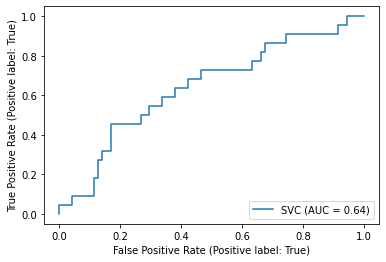

In [165]:
svc_disp = RocCurveDisplay.from_estimator(svc, X_test_1, y_test)
plt.show()

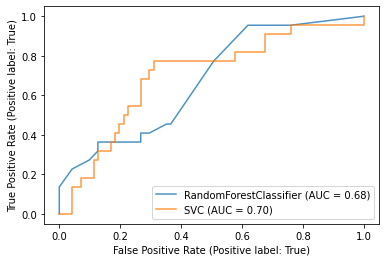

In [134]:
rfc = RandomForestClassifier(n_estimators=10, random_state=42)
rfc.fit(X_train_1, y_train)
ax = plt.gca()
rfc_disp = RocCurveDisplay.from_estimator(rfc, X_test_1, y_test, ax=ax, alpha=0.8)
svc_disp.plot(ax=ax, alpha=0.8)
plt.show()

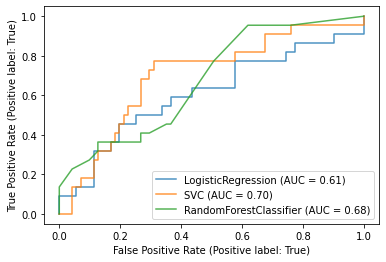

In [135]:
lr = LogisticRegression(solver='liblinear')
lr.fit(X_train_1, y_train)
ax = plt.gca()
lr_disp = RocCurveDisplay.from_estimator(lr, X_test_1, y_test, ax=ax, alpha=0.8)
svc_disp.plot(ax=ax, alpha=0.8)
rfc_disp.plot(ax=ax, alpha=0.8)
plt.show()

## 8.3 Training for deployment  

Below, the model is trained on the whole dataset, and can be deployed.

In [163]:
X_1 = X[: ,[34, 35, 36, 37, 38, 42]]
X_final = StandardScaler().fit_transform(X_1)
model = svm.SVC(C=C_1,gamma=gamma_1, class_weight='balanced')
model.fit(X_final,y)
yt_p = model.predict(X_final)
#print('Training Accuracy', np.mean(yt_p==y))
confusion_matrix(y, yt_p)

array([[277,  77],
       [ 52,  56]])

# 9 Conclusions

Your conclusions, improvements, etc should go here  

The classifier seems to be moderately successful at identifying indoor vs. outdoor sounds, with a testing accuracy of 66 %. 

Further areas for development could be:  
- Deeper understanding of extracted features (domain knowledge of sound analysis would be useful here).
- 